In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter1d
from sunpy.coordinates import Helioprojective, SphericalScreen, propagate_with_solar_surface
from astropy.wcs import WCS
from gaussian_fit import fit_gaussian, fit_double_gaussian
import matplotlib.ticker as ticker
from matplotlib.path import Path

这个是用来画HMI图像看是否有磁流涌现的

In [6]:
hmi_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\*.fits')
map23=sunpy.map.Map(hmi_list[23]).rotate()
bottom_left=SkyCoord(Tx=330*u.arcsec,Ty=-410*u.arcsec,frame=map23.coordinate_frame)
top_right=SkyCoord(Tx=380*u.arcsec,Ty=-360*u.arcsec,frame=map23.coordinate_frame)
sub_map23=map23.submap(bottom_left,top_right=top_right)

for i in range(len(hmi_list)):
    if i!=23:
        mapi=sunpy.map.Map(hmi_list[i]).rotate()
        with propagate_with_solar_surface():
            sub_mapi=mapi.reproject_to(sub_map23.wcs,preserve_date_obs=True)
        sub_mapi.meta["bunit"] = mapi.meta["bunit"]
    else:
        sub_mapi=sub_map23
    # 画出 +200 Gauss 等值线
    
    bottom_left2=SkyCoord(Tx=342*u.arcsec,Ty=-395*u.arcsec,frame=mapi.coordinate_frame)
    top_right2=SkyCoord(Tx=366*u.arcsec,Ty=-378*u.arcsec,frame=mapi.coordinate_frame)
    
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection=sub_mapi)
    plot_mapi = sub_mapi.plot(axes=ax, cmap='gray')
    plot_mapi.set_clim(-400, 400)
    contours = sub_mapi.draw_contours(
            levels=[-50,50] * u.G,
            axes=ax,
            colors=['blue','red'],
            linewidths=1.2,
        )
    sub_mapi.draw_quadrangle(bottom_left2,top_right=top_right2,axes=ax,edgecolor='yellow',linewidth=1.5)
    plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI_subfig_2\HMI_subfig_{:02d}.png'.format(i), dpi=300)
    plt.close()

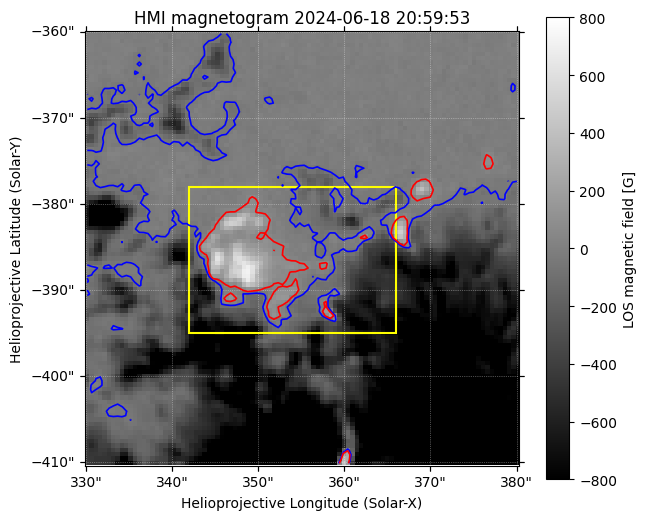

In [3]:
hmi_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\*.fits')
map23=sunpy.map.Map(hmi_list[0]).rotate()
bottom_left=SkyCoord(Tx=330*u.arcsec,Ty=-410*u.arcsec,frame=map23.coordinate_frame)
top_right=SkyCoord(Tx=380*u.arcsec,Ty=-360*u.arcsec,frame=map23.coordinate_frame)
sub_map23=map23.submap(bottom_left,top_right=top_right)
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection=sub_map23)

plot_map23 = sub_map23.plot(axes=ax, cmap='gray')
plot_map23.set_clim(-800, 800)

# 画出 +200 Gauss 等值线
contours = sub_map23.draw_contours(
    levels=[-50,50] * u.G,
    axes=ax,
    colors=['blue','red'],
    linewidths=1.2,
)
bottom_left2=SkyCoord(Tx=342*u.arcsec,Ty=-395*u.arcsec,frame=map23.coordinate_frame)
top_right2=SkyCoord(Tx=366*u.arcsec,Ty=-378*u.arcsec,frame=map23.coordinate_frame)
sub_map23.draw_quadrangle(bottom_left2,top_right=top_right2,axes=ax,edgecolor='yellow',linewidth=1.5)
fig.colorbar(plot_map23, ax=ax, label='LOS magnetic field [G]')
plt.show()

In [1]:
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface

hmi_list = glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\*.fits')
output_dir = Path(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI_subfig_3')
output_dir.mkdir(parents=True, exist_ok=True)

map23 = sunpy.map.Map(hmi_list[23]).rotate()
bottom_left = SkyCoord(Tx=330*u.arcsec, Ty=-410*u.arcsec, frame=map23.coordinate_frame)
top_right = SkyCoord(Tx=380*u.arcsec, Ty=-360*u.arcsec, frame=map23.coordinate_frame)
sub_map23 = map23.submap(bottom_left, top_right=top_right)

# 在参考帧中定义固定的黄色矩形
bottom_left2 = SkyCoord(Tx=342*u.arcsec, Ty=-395*u.arcsec, frame=sub_map23.coordinate_frame)
top_right2 = SkyCoord(Tx=366*u.arcsec, Ty=-378*u.arcsec, frame=sub_map23.coordinate_frame)

import numpy as np
from matplotlib.patches import Polygon

# 斜矩形参数：中心坐标和长宽的单位均为角秒
cx, cy = 347.5, -388.5
length, width = 9.0, 5.0
angle = -65.0  # 长边相对 Solar-X 正方向的角度，逆时针为正

# 以矩形中心为原点，定义四个顶点并旋转
theta = np.deg2rad(angle)
rotation = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
corners = np.array([[-length/2, -width/2], [length/2, -width/2], [length/2, width/2], [-length/2, width/2]])
corners = corners @ rotation.T + np.array([cx, cy])

# 转换为参考图上的像素坐标
rect_coords = SkyCoord(Tx=corners[:, 0]*u.arcsec, Ty=corners[:, 1]*u.arcsec, frame=sub_map23.coordinate_frame)
px, py = sub_map23.world_to_pixel(rect_coords)
rect_pixels = np.column_stack([px.to_value(u.pix), py.to_value(u.pix)])

for i in range(len(hmi_list)):
    if i != 23:
        mapi = sunpy.map.Map(hmi_list[i]).rotate()
        with propagate_with_solar_surface():
            sub_mapi = mapi.reproject_to(sub_map23.wcs, preserve_date_obs=True)
        sub_mapi.meta["bunit"] = mapi.meta["bunit"]
    else:
        sub_mapi = sub_map23

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection=sub_mapi)
    plot_mapi = sub_mapi.plot(axes=ax, cmap='gray')
    plot_mapi.set_clim(-800, 800)
    bounds = ax.axis()

    # 蓝色：-50 G；红色：+50 G
    #sub_mapi.draw_contours(levels=[-50, 50]*u.G, axes=ax, colors=['blue', 'red'], linewidths=1.2)

    # 绿色：0 G 等值线，即该磁场分量的极性反转线
    #sub_mapi.draw_contours(levels=[0]*u.G, axes=ax, colors='lime', linewidths=1.0, zorder=5)

    sub_mapi.draw_quadrangle(bottom_left2, top_right=top_right2, axes=ax, edgecolor='yellow', linewidth=1.5)
    rect = Polygon(rect_pixels, closed=True, fill=False, edgecolor='magenta', linewidth=1.8, zorder=10)
    #ax.add_patch(rect)
    ax.axis(bounds)
    fig.savefig(output_dir / f'HMI_subfig_{i:02d}.png', dpi=300)
    plt.close(fig)

In [10]:
print("DATE-OBS:", map23.meta.get('date-obs'))
print("TIMESYS:", map23.meta.get('timesys'))
print("SunPy 读取的时间:", map23.date)
print("SunPy 读取的时间尺度:", map23.date.scale)
print("UTC 表示:", map23.date.utc.isot)

DATE-OBS: 2024-06-18T21:17:08.400
TIMESYS: None
SunPy 读取的时间: 2024-06-18T21:17:08.400
SunPy 读取的时间尺度: utc
UTC 表示: 2024-06-18T21:17:08.400


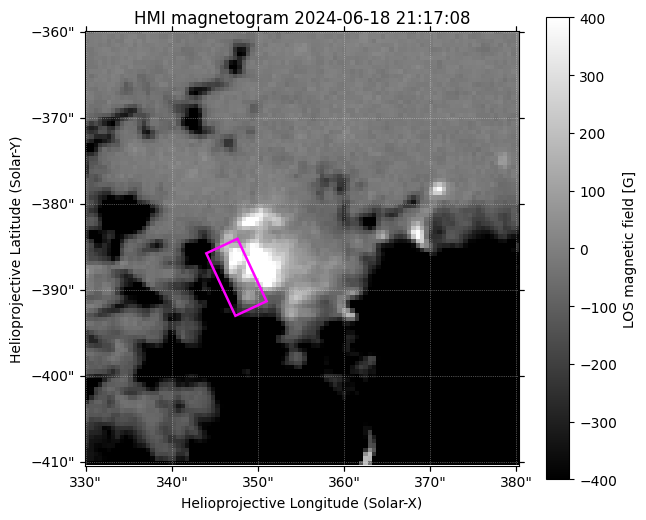

选区像素数：127，参考表面面积：2.1000e+17 cm²
2024-06-18 20:59:53.400000  正：2.3430e+19 Mx，负：-2.1912e+19 Mx
2024-06-18 21:00:38.400000  正：2.3717e+19 Mx，负：-2.1828e+19 Mx
2024-06-18 21:01:23.400000  正：2.4014e+19 Mx，负：-2.1810e+19 Mx
2024-06-18 21:02:08.400000  正：2.4224e+19 Mx，负：-2.2189e+19 Mx
2024-06-18 21:02:53.400000  正：2.4012e+19 Mx，负：-2.2724e+19 Mx
2024-06-18 21:03:38.400000  正：2.3961e+19 Mx，负：-2.3081e+19 Mx
2024-06-18 21:04:23.400000  正：2.4252e+19 Mx，负：-2.2791e+19 Mx
2024-06-18 21:05:08.400000  正：2.4958e+19 Mx，负：-2.2793e+19 Mx
2024-06-18 21:05:53.400000  正：2.4520e+19 Mx，负：-2.2294e+19 Mx
2024-06-18 21:06:38.400000  正：2.4136e+19 Mx，负：-2.2397e+19 Mx
2024-06-18 21:07:23.400000  正：2.4745e+19 Mx，负：-2.2712e+19 Mx
2024-06-18 21:08:08.400000  正：2.5638e+19 Mx，负：-2.3108e+19 Mx
2024-06-18 21:08:53.400000  正：2.6293e+19 Mx，负：-2.3726e+19 Mx
2024-06-18 21:09:38.400000  正：2.6457e+19 Mx，负：-2.4008e+19 Mx
2024-06-18 21:10:23.400000  正：2.6429e+19 Mx，负：-2.3853e+19 Mx
2024-06-18 21:11:08.400000  正：2.5841e+19 Mx，负：-2.3589

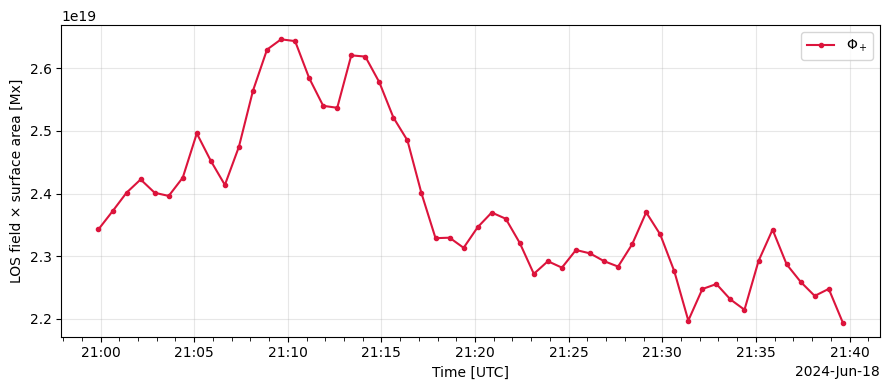

In [12]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Polygon
import astropy.units as u
from astropy.coordinates import SkyCoord
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface

# 1. 读取参考帧
hmi_list = sorted(glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\*.fits'))
ref_index = 23
if len(hmi_list) <= ref_index:
    raise ValueError(f"仅找到 {len(hmi_list)} 个文件，无法读取索引 {ref_index}")

map23 = sunpy.map.Map(hmi_list[ref_index]).rotate()
bottom_left = SkyCoord(Tx=330*u.arcsec, Ty=-410*u.arcsec, frame=map23.coordinate_frame)
top_right = SkyCoord(Tx=380*u.arcsec, Ty=-360*u.arcsec, frame=map23.coordinate_frame)
sub_map23 = map23.submap(bottom_left, top_right=top_right)

# 2. 定义紫色斜矩形：位置、长宽单位为角秒，角度单位为度
cx, cy = 347.5, -388.5
length, width = 8.0, 4.0
angle = -65.0
threshold = 0.0  # G；设为 50.0 时，仅统计 B > 50 G 和 B < -50 G
if length <= 0 or width <= 0 or threshold < 0:
    raise ValueError("矩形长宽必须大于零，磁场阈值不能为负")

theta = np.deg2rad(angle)
c, s = np.cos(theta), np.sin(theta)

# 计算矩形顶点，用于绘图
rotation = np.array([[c, -s], [s, c]])
corners = np.array([[-length/2, -width/2], [length/2, -width/2], [length/2, width/2], [-length/2, width/2]])
corners = corners @ rotation.T + np.array([cx, cy])
rect_coords = SkyCoord(Tx=corners[:, 0]*u.arcsec, Ty=corners[:, 1]*u.arcsec, frame=sub_map23.coordinate_frame)
px, py = sub_map23.world_to_pixel(rect_coords)
rect_pixels = np.column_stack([px.to_value(u.pix), py.to_value(u.pix)])

# 3. 将像素中心反向旋转到矩形自身的坐标系，构造掩膜
y, x = np.indices(sub_map23.data.shape)
coords = sub_map23.pixel_to_world(x*u.pix, y*u.pix)
offset_x = coords.Tx.to_value(u.arcsec) - cx
offset_y = coords.Ty.to_value(u.arcsec) - cy
local_x = c*offset_x + s*offset_y
local_y = -s*offset_x + c*offset_y
mask = (np.abs(local_x) <= length/2) & (np.abs(local_y) <= width/2)
if not mask.any():
    raise ValueError("斜矩形内没有像素，请检查位置、长宽和角度")
coords_in = coords[mask]

# 绘制参考帧，检查统计区域
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection=sub_map23)
im = sub_map23.plot(axes=ax, cmap='gray')
im.set_clim(-400, 400)
bounds = ax.axis()
ax.add_patch(Polygon(rect_pixels, closed=True, fill=False, edgecolor='magenta', linewidth=1.8, zorder=10))
ax.axis(bounds)
fig.colorbar(im, ax=ax, label='LOS magnetic field [G]')
plt.show()

# 4. 面积投影校正：仅校正面积，不校正磁场
disk_center = SkyCoord(Tx=0*u.arcsec, Ty=0*u.arcsec, frame=sub_map23.coordinate_frame)
rho = coords_in.separation(disk_center).to_value(u.rad)
solar_radius = sub_map23.rsun_obs.to_value(u.rad)
sin_theta = np.sin(rho) / np.sin(solar_radius)
mu0 = np.sqrt(np.clip(1 - sin_theta**2, 0, 1))
if np.any(~np.isfinite(mu0) | (mu0 <= 0)):
    raise ValueError("选中区域包含日面边缘或日面外的位置")

dx = abs(sub_map23.scale.axis1.to_value(u.rad/u.pix))
dy = abs(sub_map23.scale.axis2.to_value(u.rad/u.pix))
D0 = sub_map23.dsun.to_value(u.cm)
area_projected = D0**2 * dx * dy
area_surface = area_projected / mu0  # cm²，小角度、远观测者近似

print(f"选区像素数：{mask.sum()}，参考表面面积：{area_surface.sum():.4e} cm²")

# 5. 跟踪参考区域，逐帧计算正、负 LOS 磁场面积积分
flux_positive = np.full(len(hmi_list), np.nan)
flux_negative = np.full(len(hmi_list), np.nan)
times = []

for i, filename in enumerate(hmi_list):
    if i == ref_index:
        current_map, aligned_map = map23, sub_map23
    else:
        current_map = sunpy.map.Map(filename)
        with propagate_with_solar_surface():
            aligned_map = current_map.reproject_to(sub_map23.wcs, preserve_date_obs=True)

    times.append(current_map.date.utc.datetime)
    if current_map.unit is None:
        raise ValueError(f"文件缺少磁场单位：{filename}")
    B = (aligned_map.data[mask] * current_map.unit).to_value(u.G)

    # 缺测时不缩小统计区域，以免制造虚假的磁通量下降
    if not np.all(np.isfinite(B)):
        print(f"第 {i+1} 帧区域存在缺测，结果记为 NaN")
        continue

    positive = B > threshold
    negative = B < -threshold
    flux_positive[i] = np.sum(B[positive] * area_surface[positive])
    flux_negative[i] = np.sum(B[negative] * area_surface[negative])
    print(f"{times[-1]}  正：{flux_positive[i]:.4e} Mx，负：{flux_negative[i]:.4e} Mx")

# 6. 按实际观测时间排序
order = np.argsort(np.array(times, dtype='datetime64[us]'))
times = np.asarray(times)[order]
flux_positive = flux_positive[order]
flux_negative = flux_negative[order]

# 净积分和无符号积分；threshold > 0 时，仅包含超过阈值的像素
flux_net = flux_positive + flux_negative
flux_unsigned = flux_positive - flux_negative

# 7. 绘制正极性和负极性绝对值的时间曲线
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(times, flux_positive, '.-', color='crimson', label=r'$\Phi_+$')
#ax.plot(times, np.abs(flux_negative), '.-', color='royalblue', label=r'$|\Phi_-|$')
ax.set_xlabel('Time [UTC]')
ax.set_ylabel('LOS field × surface area [Mx]')
ax.grid(alpha=0.3)
ax.legend()
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
ax.tick_params(axis='x', which='minor', length=3)
plt.tight_layout()
plt.show()

In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Polygon
import astropy.units as u
from astropy.coordinates import SkyCoord
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface

# 1. 读取参考帧
hmi_list = sorted(glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI3\*.fits'))
ref_index = 23
if len(hmi_list) <= ref_index:
    raise ValueError(f"仅找到 {len(hmi_list)} 个文件，无法读取索引 {ref_index}")

map23 = sunpy.map.Map(hmi_list[ref_index]).rotate()
bottom_left = SkyCoord(Tx=330*u.arcsec, Ty=-410*u.arcsec, frame=map23.coordinate_frame)
top_right = SkyCoord(Tx=380*u.arcsec, Ty=-360*u.arcsec, frame=map23.coordinate_frame)
sub_map23 = map23.submap(bottom_left, top_right=top_right)

# 2. 定义紫色斜矩形：位置、长宽单位为角秒，角度单位为度
cx, cy = 347.5, -388.5
length, width = 8.0, 4.0
angle = -65.0
threshold = 0.0  # G；设为 50.0 时，仅统计 B > 50 G 和 B < -50 G
if length <= 0 or width <= 0 or threshold < 0:
    raise ValueError("矩形长宽必须大于零，磁场阈值不能为负")

theta = np.deg2rad(angle)
c, s = np.cos(theta), np.sin(theta)

# 计算矩形顶点，用于绘图
rotation = np.array([[c, -s], [s, c]])
corners = np.array([[-length/2, -width/2], [length/2, -width/2], [length/2, width/2], [-length/2, width/2]])
corners = corners @ rotation.T + np.array([cx, cy])
rect_coords = SkyCoord(Tx=corners[:, 0]*u.arcsec, Ty=corners[:, 1]*u.arcsec, frame=sub_map23.coordinate_frame)
px, py = sub_map23.world_to_pixel(rect_coords)
rect_pixels = np.column_stack([px.to_value(u.pix), py.to_value(u.pix)])

# 3. 将像素中心反向旋转到矩形自身的坐标系，构造掩膜
y, x = np.indices(sub_map23.data.shape)
coords = sub_map23.pixel_to_world(x*u.pix, y*u.pix)
offset_x = coords.Tx.to_value(u.arcsec) - cx
offset_y = coords.Ty.to_value(u.arcsec) - cy
local_x = c*offset_x + s*offset_y
local_y = -s*offset_x + c*offset_y
mask = (np.abs(local_x) <= length/2) & (np.abs(local_y) <= width/2)
if not mask.any():
    raise ValueError("斜矩形内没有像素，请检查位置、长宽和角度")
coords_in = coords[mask]

# 绘制参考帧，检查统计区域
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection=sub_map23)
im = sub_map23.plot(axes=ax, cmap='gray')
im.set_clim(-400, 400)
bounds = ax.axis()
ax.add_patch(Polygon(rect_pixels, closed=True, fill=False, edgecolor='magenta', linewidth=1.8, zorder=10))
ax.axis(bounds)
fig.colorbar(im, ax=ax, label='LOS magnetic field [G]')
plt.show()

# 4. 面积投影校正：仅校正面积，不校正磁场
disk_center = SkyCoord(Tx=0*u.arcsec, Ty=0*u.arcsec, frame=sub_map23.coordinate_frame)
rho = coords_in.separation(disk_center).to_value(u.rad)
solar_radius = sub_map23.rsun_obs.to_value(u.rad)
sin_theta = np.sin(rho) / np.sin(solar_radius)
mu0 = np.sqrt(np.clip(1 - sin_theta**2, 0, 1))
if np.any(~np.isfinite(mu0) | (mu0 <= 0)):
    raise ValueError("选中区域包含日面边缘或日面外的位置")

dx = abs(sub_map23.scale.axis1.to_value(u.rad/u.pix))
dy = abs(sub_map23.scale.axis2.to_value(u.rad/u.pix))
D0 = sub_map23.dsun.to_value(u.cm)
area_projected = D0**2 * dx * dy
area_surface = area_projected / mu0  # cm²，小角度、远观测者近似

print(f"选区像素数：{mask.sum()}，参考表面面积：{area_surface.sum():.4e} cm²")

# 5. 跟踪参考区域，逐帧计算正、负 LOS 磁场面积积分
flux_positive = np.full(len(hmi_list), np.nan)
flux_negative = np.full(len(hmi_list), np.nan)
times = []

for i, filename in enumerate(hmi_list):
    if i == ref_index:
        current_map, aligned_map = map23, sub_map23
    else:
        current_map = sunpy.map.Map(filename)
        with propagate_with_solar_surface():
            aligned_map = current_map.reproject_to(sub_map23.wcs, preserve_date_obs=True)

    times.append(current_map.date.utc.datetime)
    if current_map.unit is None:
        raise ValueError(f"文件缺少磁场单位：{filename}")
    B = (aligned_map.data[mask] * current_map.unit).to_value(u.G)

    # 缺测时不缩小统计区域，以免制造虚假的磁通量下降
    if not np.all(np.isfinite(B)):
        print(f"第 {i+1} 帧区域存在缺测，结果记为 NaN")
        continue

    positive = B > threshold
    negative = B < -threshold
    flux_positive[i] = np.sum(B[positive] * area_surface[positive])
    flux_negative[i] = np.sum(B[negative] * area_surface[negative])
    print(f"{times[-1]}  正：{flux_positive[i]:.4e} Mx，负：{flux_negative[i]:.4e} Mx")

# 6. 按实际观测时间排序
order = np.argsort(np.array(times, dtype='datetime64[us]'))
times = np.asarray(times)[order]
flux_positive = flux_positive[order]
flux_negative = flux_negative[order]

# 净积分和无符号积分；threshold > 0 时，仅包含超过阈值的像素
flux_net = flux_positive + flux_negative
flux_unsigned = flux_positive - flux_negative

# 7. 绘制正极性和负极性绝对值的时间曲线
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(times, flux_positive, '.-', color='crimson', label=r'$\Phi_+$')
#ax.plot(times, np.abs(flux_negative), '.-', color='royalblue', label=r'$|\Phi_-|$')
ax.set_xlabel('Time [UTC]')
ax.set_ylabel('LOS field × surface area [Mx]')
ax.grid(alpha=0.3)
ax.legend()
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
ax.tick_params(axis='x', which='minor', length=3)
plt.tight_layout()
plt.show()